# Reinforcement Learning

# 4. Online control

This notebook presents the **online control** of an agent by SARSA and Q-learning.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from model import TicTacToe, Nim, ConnectFour
from agent import Agent, OnlineControl
from dynamic import ValueIteration

## To do

* Complete the class ``SARSA`` and test it on Tic-Tac-Toe.
* Complete the class ``QLearning`` and test it on Tic-Tac-Toe.
* Compare these algorithms on Tic-Tac-Toe (play first) and Nim (play second), using a random adversary, then a perfect adversary. Comment your results.
* Test these algorithms on Connect 4 against a random adversary. Comment your results.

## SARSA

In [4]:
class SARSA(OnlineControl):
    """Online control by SARSA."""
        
    def update_values(self, state=None, horizon=100, epsilon=0.5):
        """Learn the action-value function online."""
        self.model.reset(state)
        state = self.model.state
        if not self.model.is_terminal(state):
            action = self.randomize_best_action(state, epsilon=epsilon)
            for t in range(horizon):
                code = self.model.encode(state)
                self.action_count[code][action] += 1
                reward, stop = self.model.step(action)
                # to be modified (get sample gain)
                # begin
                if not stop:
                    next_state = self.model.state
                    next_code = self.model.encode(next_state)
                    next_action = self.randomize_best_action(next_state, epsilon=epsilon)
                    gain = reward + self.gamma * self.action_value[next_code][next_action]
                else:
                    gain = reward
                # end
                diff = gain - self.action_value[code][action]
                count = self.action_count[code][action]
                self.action_value[code][action] += diff / count
                if stop:
                    break
                # to be modified (update state and action)
                # begin
                state = next_state
                action = next_action
                # end

## Q-learning

In [5]:
class QLearning(OnlineControl):
    """Online control by Q-learning."""
        
    def update_values(self, state=None, horizon=100, epsilon=0.5):
        """Learn the action-value function online."""
        self.model.reset(state)
        state = self.model.state
        # to be completed
        if not self.model.is_terminal(state):
            for t in range(horizon):
                code = self.model.encode(state)
                action = self.randomize_best_action(state, epsilon=epsilon)
                self.action_count[code][action] += 1
                reward, stop = self.model.step(action)

                if not stop:
                    next_state = self.model.state
                    next_code = self.model.encode(next_state)
                    next_action = self.randomize_best_action(next_state, epsilon=0)
                    gain = reward + self.gamma * self.action_value[next_code][next_action]
                else:
                    gain = reward

                diff = gain - self.action_value[code][action]
                count = self.action_count[code][action]
                self.action_value[code][action] += diff / count

                if stop:
                    break

                state = next_state
                    

## To do

In [13]:
def run_training(Game, Algo, adversary_policy='random', n_games=1000, epsilon=0.5, step=None, verbose=False):
    game = Game(adversary_policy=adversary_policy)
    algo = Algo(game, policy='random')
    gains = []

    if verbose:
        print("Game: {}".format(Game.__name__))
        if isinstance(adversary_policy, str):
            print("Adversary: {}".format(adversary_policy))
        else:
            print("Adversary: costum")
        print("Learning algorithm: {}".format(Algo.__name__), end='\n\n')

    for t in range(n_games):
        algo.update_values(epsilon=epsilon)
        if step and (t+1)%step == 0:
            policy_improved = algo.get_policy()
            agent = Agent(game, policy=policy_improved)
            gain = np.mean(agent.get_gains())
            gains.append(gain)
            if verbose:
                print("Gain after {} games: {}".format(t+1, gain))

    policy_improved = algo.get_policy()
    agent = Agent(game, policy=policy_improved)
        
    results = dict(zip(*np.unique(agent.get_gains(), return_counts=True)))
    gain = np.mean(agent.get_gains())

    if verbose:
        print() if step else None
        print("--Final policy--")
        print("Losses: {}".format(results[-1] if -1 in results else 0))
        print("Draws: {}".format(results[0] if 0 in results else 0))
        print("Wins: {}".format(results[1] if 1 in results else 0))
        
    return gains if step else gain

In [45]:
def plot_gains(data_dict, adversary_policy, num_episodes, step):
    # X-axis values
    games = np.arange(0, num_episodes + 1, step)[1:]

    # Plot
    plt.figure(figsize=(6, 4))
    for key, values in data_dict.items():
        plt.plot(games, values, label=f"{key}", marker="o")

    # Labels, title, and legend
    plt.xlabel("Games")
    plt.ylabel("Gain")
    plt.title(f"{adversary_policy.title()} adversary")
    plt.legend(title="Epsilon", loc="best")
    plt.ylim(-1, 1)

    # Show plot
    plt.tight_layout()
    plt.show()

### Random agent on TicTacToe

In [7]:
Game = TicTacToe
game = Game()
agent = Agent(game)

results = dict(zip(*np.unique(agent.get_gains(), return_counts=True)))

In [8]:
print("Losses: {}".format(results[-1] if -1 in results else 0))
print("Draws: {}".format(results[0] if 0 in results else 0))
print("Wins: {}".format(results[1] if 1 in results else 0))

Losses: 27
Draws: 16
Wins: 57


### SARSA on TicTacToe

In [9]:
gain = run_training(Game, SARSA, adversary_policy='random', n_games=1000, epsilon=0.1, verbose=True)

Game: TicTacToe
Adversary: random
Learning algorithm: SARSA

--Final policy--
Losses: 4
Draws: 2
Wins: 94


### QLearning on TicTacToe

In [10]:
gain = run_training(Game, SARSA, adversary_policy='random', n_games=1000, epsilon=0.1, verbose=True)

Game: TicTacToe
Adversary: random
Learning algorithm: SARSA

--Final policy--
Losses: 2
Draws: 5
Wins: 93


## TicTacToe: SARSA

In [18]:
epsilons = [0.05, 0.1, 0.5]

### Random player

In [ ]:
sarsa_tictactoe_random_gains = {epsilon: run_training(TicTacToe, SARSA, adversary_policy='random', n_games=1000, epsilon=epsilon, step=100) for epsilon in epsilons}

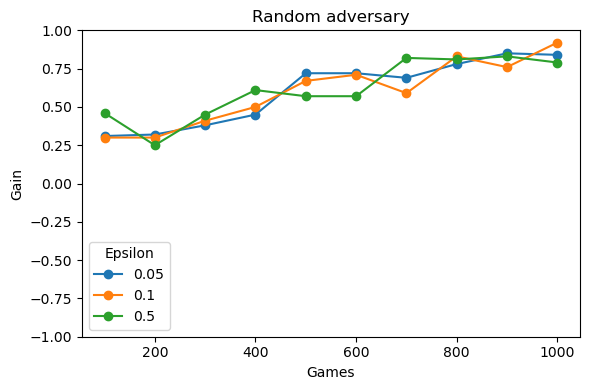

In [47]:
plot_gains(sarsa_tictactoe_random_gains, 'random', 1000, 100)

### Perfect player

In [20]:
game = TicTacToe()

algo = ValueIteration(game)
policy, adversary_policy = algo.get_perfect_players()

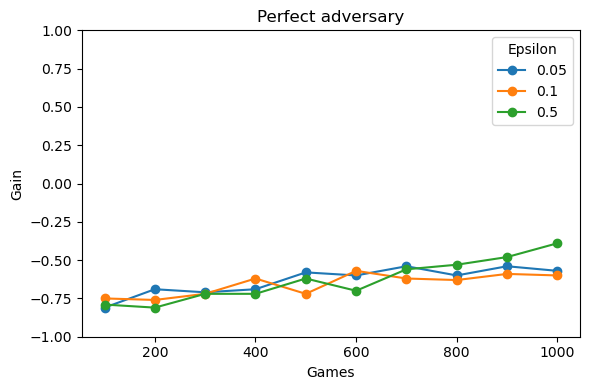

In [56]:
n_games = 1000

sarsa_tictactoe_perfect_gains = {epsilon: run_training(TicTacToe, SARSA, adversary_policy=adversary_policy, n_games=n_games, epsilon=epsilon, step=100) for epsilon in epsilons}

plot_gains(sarsa_tictactoe_perfect_gains, 'perfect', n_games, 100)

## TicTacToe: QLearning

In [48]:
epsilons = [0.05, 0.1, 0.5]

### Random player

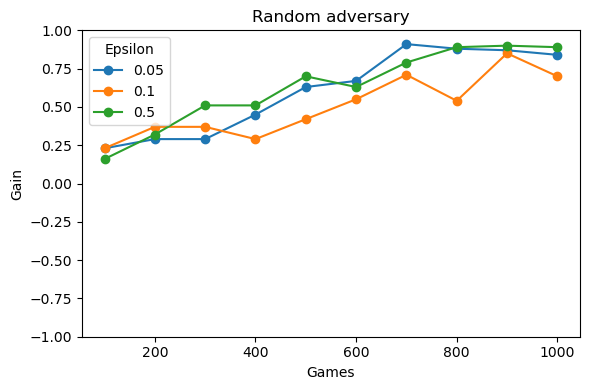

In [49]:
qlearning_tictactoe_random_gains = {epsilon: run_training(TicTacToe, QLearning, adversary_policy='random', n_games=1000, epsilon=epsilon, step=100) for epsilon in epsilons}

plot_gains(qlearning_tictactoe_random_gains, 'random', 1000, 100)

### Perfect player

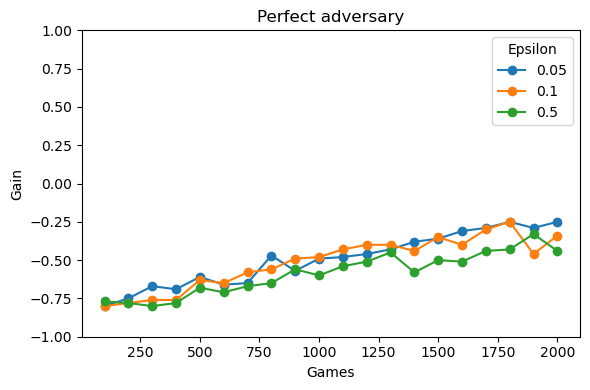

In [52]:
n_games = 2000

qlearning_tictactoe_perfect_gains = {epsilon: run_training(TicTacToe, QLearning, adversary_policy=adversary_policy, n_games=n_games, epsilon=epsilon, step=100) for epsilon in epsilons}

plot_gains(qlearning_tictactoe_perfect_gains, 'perfect', n_games, 100)